In [ ]:
%pip install sec-api

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 1.1 MB/s eta 0:00:00


# Tool 1. Read Text from SEC API

You can obtain your own free SEC API key at the link below.
https://sec-api.io/

Documentation:
https://sec-api.io/docs

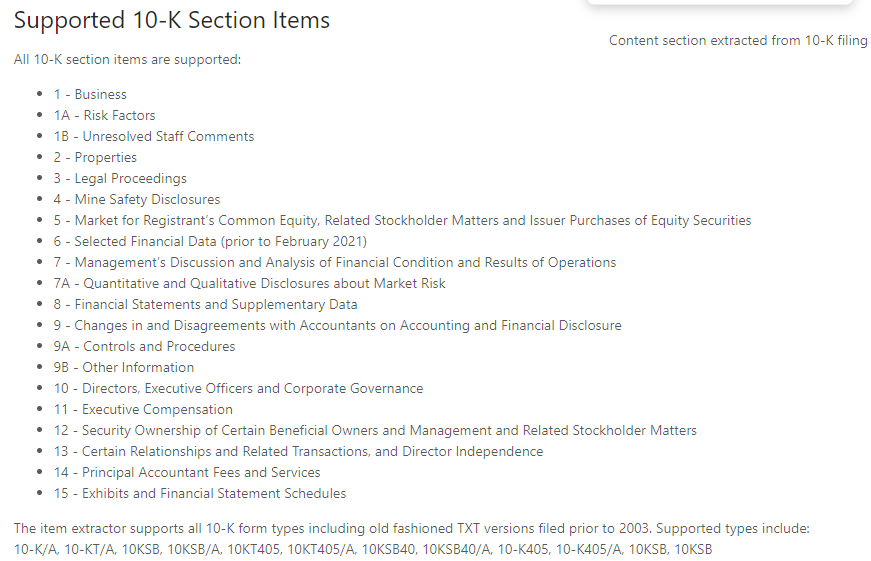

In [ ]:
# Enter your own SEC API key
sec_api = "dcebc8a5c4199429a56121912d38b983e018978150681aac1fb69ee2b99b57d2"

In [ ]:
from sec_api import ExtractorApi
from IPython.display import display, HTML

extractorApi = ExtractorApi(sec_api)

# 10-K example
url_10k_nvda = "https://www.sec.gov/ix?doc=/Archives/edgar/data/0001045810/000104581025000023/nvda-20250126.htm"
url_10k_qcom = "https://www.sec.gov/ix?doc=/Archives/edgar/data/0000804328/000080432824000075/qcom-20240929.htm"

item_7_text_nvda = extractorApi.get_section(url_10k_nvda, "7", "text")
item_7_text_qcom = extractorApi.get_section(url_10k_qcom, "7", "text")

item_7_html_nvda = extractorApi.get_section(url_10k_nvda, "7", "html")
item_7_html_qcom = extractorApi.get_section(url_10k_qcom, "7", "html")

In [ ]:
item_7_text_nvda

' Item 7. Management\'s Discussion and Analysis of Financial Condition and Results of Operations \n\nThe following discussion and analysis of our financial condition and results of operations should be read in conjunction with &#8220;Item 1A. Risk Factors,&#8221; our Consolidated Financial Statements and related Notes thereto, as well as other cautionary statements and risks described elsewhere in this Annual Report on Form 10-K, before deciding to purchase, hold, or sell shares of our common stock. \n\nOverview \n\nOur Company and Our Businesses \n\nNVIDIA pioneered accelerated computing to help solve the most challenging computational problems. Since our original focus on PC graphics, we have expanded to several other large and important computationally intensive fields. Fueled by the sustained demand for exceptional 3D graphics and the scale of the gaming market, NVIDIA has leveraged its GPU architecture to create platforms for scientific computing, AI, data science, AV, robotics, a

In [ ]:
# To view the text in an HTML format
display(HTML(item_7_html_nvda))

# Tool 2. Use OpenAI API for Prompt Requests with the 10-K Text

In [ ]:
%pip install openai

In [ ]:
from openai import OpenAI
# Please use the API Key specific for this class
api_key = os.environ.get("OPENAI_API_KEY", "")  # Set in env; never commit real keys
client = OpenAI(api_key=api_key)

# **Overall Task:** I want to decide whether to sell NVDA's Stocks due to the recent news on the Google, Intel, and Qualcomm consortium

*Please feel free to be creative!*

Examples:

- Loan issuers
- ESG raters (risk management)

## **Creative Task 1.** Use ChatGPT to extract the relevant information you want to compare with other companies, **qualitatively** and **quantitatively**

###**Qualitative Example 1:** Simply ask for a summary





In [ ]:
prompt = "Provided text is the item 7 (Management's Discussion and Analysis) of Nvidia's 10-K filing. Please summarize the text at maximum of 15 sentences."

response = client.chat.completions.create(
  model="gpt-3.5-turbo-0125",
  messages=[
      {"role": "system",
       "content": prompt
       },
      {"role": "user",
       "content": item_7_text_nvda
      }
  ]
)

response.choices[0].message.content

"Nvidia's Management's Discussion and Analysis outlines the company's expansion beyond PC graphics and into fields like AI, data science, AV, and robotics. The report highlights the company's operating segments, Compute & Networking and Graphics, as well as recent developments such as revenue growth fueled by data center compute, product transitions, and new product introductions. The text delves into global trade regulations impacting exports to China and other regions, potential challenges related to geopolitical conflicts, and macroeconomic factors affecting operations.\n\nIn terms of financials, revenue for fiscal year 2025 saw a significant increase of 114%, with strong growth seen in Data Center, Gaming, Professional Visualization, and Automotive segments. Operating income also surged by 147%, driven by demand for accelerated computing solutions. The report discusses critical accounting estimates related to inventories, income taxes, and revenue recognition.\n\nIt further provide

In [ ]:
nvda_summary = response.choices[0].message.content

In [ ]:
print(nvda_summary)

Nvidia's Management's Discussion and Analysis outlines the company's expansion beyond PC graphics and into fields like AI, data science, AV, and robotics. The report highlights the company's operating segments, Compute & Networking and Graphics, as well as recent developments such as revenue growth fueled by data center compute, product transitions, and new product introductions. The text delves into global trade regulations impacting exports to China and other regions, potential challenges related to geopolitical conflicts, and macroeconomic factors affecting operations.

In terms of financials, revenue for fiscal year 2025 saw a significant increase of 114%, with strong growth seen in Data Center, Gaming, Professional Visualization, and Automotive segments. Operating income also surged by 147%, driven by demand for accelerated computing solutions. The report discusses critical accounting estimates related to inventories, income taxes, and revenue recognition.

It further provides ins

In [ ]:
prompt = "Provided text is the item 7 (Management's Discussion and Analysis) of Qualcomm's 10-K filing. Please summarize the text at maximum of 15 sentences."

response = client.chat.completions.create(
  model="gpt-3.5-turbo-0125",
  messages=[
      {"role": "system",
       "content": prompt
       },
      {"role": "user",
       "content": item_7_text_qcom
      }
  ]
)

response.choices[0].message.content

"Qualcomm's management discussed the financial condition and operational results of the company in item 7 of their 10-K filing. The report details the revenue sources, operating segments, and seasonality of the business, emphasizing historical revenue fluctuations based on consumer demand for wireless devices. In fiscal 2024, revenues were $39.0 billion, with a 9% increase from the previous year, and net income was $10.1 billion, showing a 40% increase. The report breaks down revenue changes in segments such as QCT and QTL, discussing factors affecting growth.\n\nThe report also includes discussions on costs and expenses, such as research and development, selling, general and administrative expenses, and other costs. It mentions the impact of restructuring and restructuring-related charges on the financials. The overview further delves into interest expense, investment and other income, net, and income tax expenses. Details about discontinued operations, segment results, liquidity, and

In [ ]:
qcom_summary = response.choices[0].message.content

In [ ]:
print(qcom_summary)

Qualcomm's management discussed the financial condition and operational results of the company in item 7 of their 10-K filing. The report details the revenue sources, operating segments, and seasonality of the business, emphasizing historical revenue fluctuations based on consumer demand for wireless devices. In fiscal 2024, revenues were $39.0 billion, with a 9% increase from the previous year, and net income was $10.1 billion, showing a 40% increase. The report breaks down revenue changes in segments such as QCT and QTL, discussing factors affecting growth.

The report also includes discussions on costs and expenses, such as research and development, selling, general and administrative expenses, and other costs. It mentions the impact of restructuring and restructuring-related charges on the financials. The overview further delves into interest expense, investment and other income, net, and income tax expenses. Details about discontinued operations, segment results, liquidity, and ca

# Tool 3: Quantify the qualitative sentences using FinBERT for Sentiment Analysis

1. Tone/sentiment
https://huggingface.co/yiyanghkust/finbert-tone
2. FLS (forward-looking statements)
https://huggingface.co/yiyanghkust/finbert-fls

Huang, Allen H., Hui Wang, and Yi Yang. "FinBERT: A Large Language Model for Extracting Information from Financial Text." Contemporary Accounting Research (2022).

3. Topic classification
https://huggingface.co/datasets/zeroshot/twitter-financial-news-topic

In [ ]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import pipeline
import pandas as pd
import nltk
from nltk.tokenize import sent_tokenize

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Load pre-trained FinBERT model
# This is trained at the sentence-level
finbert = BertForSequenceClassification.from_pretrained('yiyanghkust/finbert-tone', num_labels=3)
tokenizer = BertTokenizer.from_pretrained('yiyanghkust/finbert-tone')

# Create a pipeline for sentiment analysis
nlp = pipeline("sentiment-analysis", model=finbert, tokenizer=tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/533 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: yiyanghkust/finbert-tone
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
# Parse the texts in qcom_summary and nvda_summary into sentences
# NLTK's sent_tokenize() separates text into sentences
sentences_nvda_summary = sent_tokenize(nvda_summary)
sentences_qcom_summary = sent_tokenize(qcom_summary)

# Get sentiments using the finBERT pipeline
inputs_nvda_summary = tokenizer(sentences_nvda_summary, padding=True, return_tensors='pt')
inputs_qcom_summary = tokenizer(sentences_qcom_summary, padding=True, return_tensors='pt')

outputs_nvda_summary = finbert(**inputs_nvda_summary)
outputs_qcom_summary = finbert(**inputs_qcom_summary)

predictions_nvda_summary = torch.nn.functional.softmax(outputs_nvda_summary.logits, dim=-1).detach().numpy().round(3)
predictions_qcom_summary = torch.nn.functional.softmax(outputs_qcom_summary.logits, dim=-1).detach().numpy().round(3)

In [ ]:
# Access the id2label attribute from the model's config
labels = finbert.config.id2label

print(labels)

{0: 'Neutral', 1: 'Positive', 2: 'Negative'}


In [ ]:
# Create a DataFrame to display the sentiment analysis results
nvda_summary_df = pd.DataFrame({
    "Sentence": sentences_nvda_summary,
    "Neutral": predictions_nvda_summary[:, 0],
    "Positive": predictions_nvda_summary[:, 1],
    "Negative": predictions_nvda_summary[:, 2]
})

qcom_summary_df = pd.DataFrame({
    "Sentence": sentences_qcom_summary,
    "Neutral": predictions_qcom_summary[:, 0],
    "Positive": predictions_qcom_summary[:, 1],
    "Negative": predictions_qcom_summary[:, 2]
})


In [ ]:
nvda_summary_df

,Sentence,Neutral,Positive,Negative
0,Nvidia's Management's Discussion and Analysis ...,0.084,0.916,0.000
1,The report highlights the company's operating ...,0.000,1.000,0.000
2,The text delves into global trade regulations ...,0.001,0.000,0.999
3,"In terms of financials, revenue for fiscal yea...",0.000,1.000,0.000
4,"Operating income also surged by 147%, driven b...",0.000,1.000,0.000
5,The report discusses critical accounting estim...,1.000,0.000,0.000
6,It further provides insights into revenue and ...,0.998,0.002,0.000
7,"The company's liquidity and capital resources,...",1.000,0.000,0.000
8,"Lastly, the report addresses climate change im...",1.000,0.000,0.000


In [ ]:
nvda_summary_df['Sentence'][3]

'In terms of financials, revenue for fiscal year 2025 saw a significant increase of 114%, with strong growth seen in Data Center, Gaming, Professional Visualization, and Automotive segments.'

In [ ]:
qcom_summary_df

,Sentence,Neutral,Positive,Negative
0,Qualcomm's management discussed the financial ...,1.000,0.000,0.000
1,"The report details the revenue sources, operat...",1.000,0.000,0.000
2,"In fiscal 2024, revenues were $39.0 billion, w...",0.000,1.000,0.000
3,The report breaks down revenue changes in segm...,1.000,0.000,0.000
4,The report also includes discussions on costs ...,1.000,0.000,0.000
5,It mentions the impact of restructuring and re...,0.999,0.000,0.000
6,The overview further delves into interest expe...,1.000,0.000,0.000
7,"Details about discontinued operations, segment...",1.000,0.000,0.000
8,"Qualcomm mentions potential future challenges,...",0.704,0.010,0.286
9,Legal proceedings and uncertainties in the glo...,0.001,0.000,0.999


In [ ]:
qcom_summary_df['Sentence'][8]

'Qualcomm mentions potential future challenges, including technological transitions, competition, and regulatory impacts.'

In [ ]:
nvda_summary_df['w_score'] = 1 * nvda_summary_df['Positive'] + 0.5 * nvda_summary_df['Neutral'] + 0 * nvda_summary_df['Negative']
qcom_summary_df['w_score'] = 1 * qcom_summary_df['Positive'] + 0.5 * qcom_summary_df['Neutral'] + 0 * qcom_summary_df['Negative']

In [ ]:
nvda_summary_df['w_score'].describe()

,w_score
count,9.000000
mean,0.662167
std,0.348673
min,0.000500
25%,0.500000
50%,0.501000
75%,1.000000
max,1.000000


In [ ]:
qcom_summary_df['w_score'].describe()

,w_score
count,12.000000
mean,0.494625
std,0.218174
min,0.000500
25%,0.499875
50%,0.500000
75%,0.500000
max,1.000000


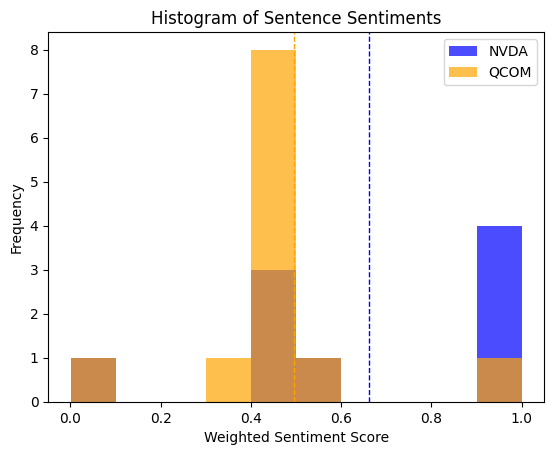

In [ ]:
# Histogram of w_scores of df_nvda

import matplotlib.pyplot as plt
# show hisogram of nvda in blue and qcom in orange

plt.hist(nvda_summary_df['w_score'], bins=10, color='blue', alpha=0.7, label = 'NVDA')
plt.hist(qcom_summary_df['w_score'], bins=10, color='orange', alpha=0.7, label = 'QCOM')

# show average w_score of nvda and qcom
plt.axvline(nvda_summary_df['w_score'].mean(), color='blue', linestyle='dashed', linewidth=1)
plt.axvline(qcom_summary_df['w_score'].mean(), color='orange', linestyle='dashed', linewidth=1)

# Set the title and the axis labels
plt.title('Histogram of Sentence Sentiments')
plt.xlabel('Weighted Sentiment Score')
plt.ylabel('Frequency')
plt.legend()

# display which color is which company
plt.show()

###**Qualitative Example 2:** Ask for a summary of the company's operational and financial results





In [ ]:
prompt = "Provided text is the item 7 (Management's Discussion and Analysis) of Nvidia's 10-K filing. Please summarize the major operational and financial results at maximum of 15 sentences."

response = client.chat.completions.create(
  model="gpt-3.5-turbo-0125",
  messages=[
      {"role": "system",
       "content": prompt
       },
      {"role": "user",
       "content": item_7_text_nvda
      }
  ]
)

response.choices[0].message.content

"In fiscal year 2025, NVIDIA's revenue increased by 114% to $130.5 billion, with Data Center revenue rising by 142%, driven by the Hopper architecture. Gaming revenue went up by 9%, while Professional Visualization revenue increased by 21%, and Automotive revenue saw a 55% growth. The gross margin improved to 75.0% due to a higher mix of Data Center revenue.\n\nOperating expenses rose by 45%, with R&D expenses up by 49% and SG&A expenses increasing by 32%. Operating income surged by 147% to $81.5 billion, and net income rose by 145% to $72.9 billion. Diluted net income per share increased by 147% to $2.94.\n\nIn terms of operational segments, Compute & Networking revenue grew by 145%, led by Data Center computing and networking increases. Graphics revenue increased by 6%, pushed by sales of GeForce RTX 40 Series GPUs. Operating income for the Compute & Networking segment grew by 159%, while the Graphics segment saw a 13% decrease.\n\nNVIDIA's liquidity remained strong, with $43.2 billi

In [ ]:
nvda_results = response.choices[0].message.content

In [ ]:
prompt = "Provided text is the item 7 (Management's Discussion and Analysis) of Qualcomm's 10-K filing. Please summarize the major operational and financial results at maximum of 15 sentences."

response = client.chat.completions.create(
  model="gpt-3.5-turbo-0125",
  messages=[
      {"role": "system",
       "content": prompt
       },
      {"role": "user",
       "content": item_7_text_qcom
      }
  ]
)

response.choices[0].message.content

"Qualcomm reported operational and financial highlights for fiscal year 2024, with revenues totaling $39.0 billion, a 9% increase over fiscal 2023, with net income at $10.1 billion, a 40% increase over the previous year. QCT segment revenues increased by 9% driven by higher handset and automotive revenues, offset by lower IoT revenues. QTL segment revenues saw a 5% increase primarily due to estimated sales growth of 3G/4G/5G-based multimode products. Other expenses decreased from $862 million in fiscal 2023 to $179 million in fiscal 2024, mainly due to lower restructuring charges. Investment and other income saw a $613 million increase in fiscal 2024. \n\nResearch and development expenses increased by $75 million due to higher share-based compensation expenses, but were partially offset by lower costs related to wireless and integrated circuit technologies. Selling, general, and administrative expenses rose by $276 million mainly due to increased sales and marketing expenses. QCT segme

In [ ]:
qcom_results = response.choices[0].message.content

In [ ]:
# @title results
# Parse the texts in qcom_summary and nvda_summary into sentences
sentences_nvda_results = sent_tokenize(nvda_results)
sentences_qcom_results = sent_tokenize(qcom_results)

# Get sentiments using the finBERT pipeline
inputs_nvda_results = tokenizer(sentences_nvda_results, padding=True, return_tensors='pt')
inputs_qcom_results = tokenizer(sentences_qcom_results, padding=True, return_tensors='pt')

outputs_nvda_results = finbert(**inputs_nvda_results)
outputs_qcom_results = finbert(**inputs_qcom_results)

predictions_nvda_results = torch.nn.functional.softmax(outputs_nvda_results.logits, dim=-1).detach().numpy().round(3)
predictions_qcom_results = torch.nn.functional.softmax(outputs_qcom_results.logits, dim=-1).detach().numpy().round(3)

In [ ]:
# Create a DataFrame to display the sentiment analysis results
nvda_results_df = pd.DataFrame({
    "Sentence": sentences_nvda_results,
    "Neutral": predictions_nvda_results[:, 0],
    "Positive": predictions_nvda_results[:, 1],
    "Negative": predictions_nvda_results[:, 2]
})

qcom_results_df = pd.DataFrame({
    "Sentence": sentences_qcom_results,
    "Neutral": predictions_qcom_results[:, 0],
    "Positive": predictions_qcom_results[:, 1],
    "Negative": predictions_qcom_results[:, 2]
})


In [ ]:
nvda_results_df['w_score'] = 1 * nvda_results_df['Positive'] + 0.5 * nvda_results_df['Neutral'] + 0 * nvda_results_df['Negative']
qcom_results_df['w_score'] = 1 * qcom_results_df['Positive'] + 0.5 * qcom_results_df['Neutral'] + 0 * qcom_results_df['Negative']

In [ ]:
nvda_results_df['w_score'].describe()

,w_score
count,13.000000
mean,0.923077
std,0.187767
min,0.499500
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


In [ ]:
qcom_results_df['w_score'].describe()

,w_score
count,14.000000
mean,0.736714
std,0.318330
min,0.000000
25%,0.504625
50%,0.891750
75%,1.000000
max,1.000000


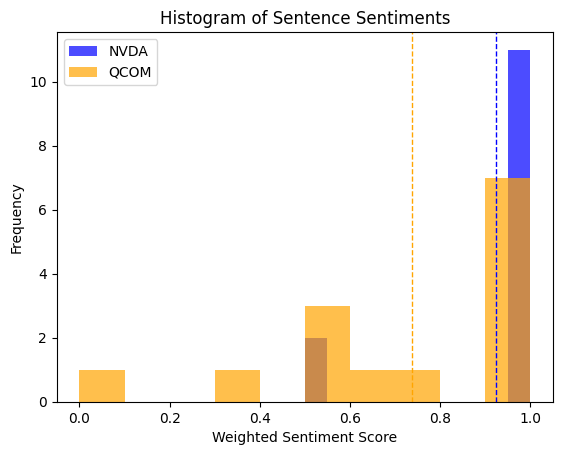

In [ ]:
# Histogram of w_scores of df_nvda

import matplotlib.pyplot as plt
# show hisogram of nvda in blue and qcom in orange

plt.hist(nvda_results_df['w_score'], bins=10, color='blue', alpha=0.7, label = 'NVDA')
plt.hist(qcom_results_df['w_score'], bins=10, color='orange', alpha=0.7, label = 'QCOM')

# show average w_score of nvda and qcom
plt.axvline(nvda_results_df['w_score'].mean(), color='blue', linestyle='dashed', linewidth=1)
plt.axvline(qcom_results_df['w_score'].mean(), color='orange', linestyle='dashed', linewidth=1)

# Set the title and the axis labels
plt.title('Histogram of Sentence Sentiments')
plt.xlabel('Weighted Sentiment Score')
plt.ylabel('Frequency')
plt.legend()

# display which color is which company
plt.show()

###**Qualitative Example 3:** Ask for a summary of the text relevant to investment decision





**Prompt:** I am an investor, trying to decide whether to buy or sell the Nvidia stock. Provided text is the item 7 (Management's Discussion and Analysis) of Nvidia's 10-K filing. Please summarize the potential risks and opportunities that may impact the company's future operations, and therefore impact the future stock price negaitvely or positively, in around 10 sentences. I will be using nltk's sent_tokenizer, so no need to use separators like '\n\n' or numberings. Just simply separate by sentences."

Note. The past part of the prompt was to optimize the response formatting to pass on for BERT processing.

In [ ]:
prompt = "I am an investor, trying to decide whether to buy or sell the Nvidia stock. Provided text is the item 7 (Management's Discussion and Analysis) of Nvidia's 10-K filing. Please summarize the potential risks and opportunities that may impact the company's future operations, and therefore impact the future stock price negaitvely or positively, in around 10 sentences. I will be using nltk's sent_tokenizer, so no need to use separators like '\n\n' or numberings. Just simply separate by sentences."

response = client.chat.completions.create(
  model="gpt-3.5-turbo-0125",
  messages=[
      {"role": "system",
       "content": prompt
       },
      {"role": "user",
       "content": item_7_text_nvda
      }
  ]
)

response.choices[0].message.content

"Nvidia's potential opportunities lie in its diversified business segments, especially in accelerated computing fields. The company has successfully expanded beyond PC graphics to areas like AI, data science, autonomous vehicles, and more, leveraging its GPU architecture. The demand for data center compute and networking platforms remains strong, with significant growth potential, driven by advancements in accelerated computing and generative AI models. Nvidia aims to enhance its supply chain and capacity to meet the increasing complexity and demand for its data center products, including entering into prepaid manufacturing and capacity agreements with suppliers.\n\nProduct transitions and new introductions present both opportunities and risks. Nvidia's strategy involves transitioning architectures in various product segments to meet the growing AI opportunities, with a focus on providing a greater variety of data center offerings. While this strategy could drive revenue growth, the in

In [ ]:
nvda_outlook = response.choices[0].message.content

In [ ]:
prompt = "I am an investor, trying to decide whether to buy or sell the Qualcomm stock. Provided text is the item 7 (Management's Discussion and Analysis) of Qualcomm's 10-K filing. Please summarize the potential risks and opportunities that may impact the company's future operations, and therefore impact the future stock price negaitvely or positively, in around 10 sentences. I will be using nltk's sent_tokenizer, so no need to use separators like '\n\n' or numberings. Just simply separate by sentences."

response = client.chat.completions.create(
  model="gpt-3.5-turbo-0125",
  messages=[
      {"role": "system",
       "content": prompt
       },
      {"role": "user",
       "content": item_7_text_qcom
      }
  ]
)

response.choices[0].message.content

"Qualcomm faces both risks and opportunities moving forward. On the positive side, the company experienced revenue growth in fiscal 2024, with net income also increasing. This growth was mainly driven by higher revenues in the QCT and QTL segments. Qualcomm's focus on developing and commercializing foundational technologies for mobile devices positions it well to benefit from advancements in 5G technology, artificial intelligence, and low-power computing. Moreover, the company's revenue streams from handset, automotive, and IoT segments indicate diversification in its product offerings. \n\nHowever, Qualcomm also faces risks that could impact its future operations. Fluctuations in consumer demand for wireless devices and the timing of device launches could affect revenues. Additionally, challenges such as ongoing disputes with licensees and governmental investigations may impact the company's QTL revenues. The company also expects continued competition, including from vertically integr

In [ ]:
qcom_outlook = response.choices[0].message.content

In [ ]:
print(nvda_outlook)

Nvidia's potential opportunities lie in its diversified business segments, especially in accelerated computing fields. The company has successfully expanded beyond PC graphics to areas like AI, data science, autonomous vehicles, and more, leveraging its GPU architecture. The demand for data center compute and networking platforms remains strong, with significant growth potential, driven by advancements in accelerated computing and generative AI models. Nvidia aims to enhance its supply chain and capacity to meet the increasing complexity and demand for its data center products, including entering into prepaid manufacturing and capacity agreements with suppliers.

Product transitions and new introductions present both opportunities and risks. Nvidia's strategy involves transitioning architectures in various product segments to meet the growing AI opportunities, with a focus on providing a greater variety of data center offerings. While this strategy could drive revenue growth, the incre

In [ ]:
print(qcom_outlook)

Qualcomm faces both risks and opportunities moving forward. On the positive side, the company experienced revenue growth in fiscal 2024, with net income also increasing. This growth was mainly driven by higher revenues in the QCT and QTL segments. Qualcomm's focus on developing and commercializing foundational technologies for mobile devices positions it well to benefit from advancements in 5G technology, artificial intelligence, and low-power computing. Moreover, the company's revenue streams from handset, automotive, and IoT segments indicate diversification in its product offerings. 

However, Qualcomm also faces risks that could impact its future operations. Fluctuations in consumer demand for wireless devices and the timing of device launches could affect revenues. Additionally, challenges such as ongoing disputes with licensees and governmental investigations may impact the company's QTL revenues. The company also expects continued competition, including from vertically integrate

In [ ]:
# @title outlook
# Parse the texts in qcom_summary and nvda_summary into sentences
sentences_nvda_outlook = sent_tokenize(nvda_outlook)
sentences_qcom_outlook = sent_tokenize(qcom_outlook)

# Get sentiments using the finBERT pipeline
inputs_nvda_outlook = tokenizer(sentences_nvda_outlook, padding=True, return_tensors='pt')
inputs_qcom_outlook = tokenizer(sentences_qcom_outlook, padding=True, return_tensors='pt')

outputs_nvda_outlook = finbert(**inputs_nvda_outlook)
outputs_qcom_outlook = finbert(**inputs_qcom_outlook)

predictions_nvda_outlook = torch.nn.functional.softmax(outputs_nvda_outlook.logits, dim=-1).detach().numpy().round(3)
predictions_qcom_outlook = torch.nn.functional.softmax(outputs_qcom_outlook.logits, dim=-1).detach().numpy().round(3)

In [ ]:
# Create a DataFrame to display the sentiment analysis results
nvda_outlook_df = pd.DataFrame({
    "Sentence": sentences_nvda_outlook,
    "Neutral": predictions_nvda_outlook[:, 0],
    "Positive": predictions_nvda_outlook[:, 1],
    "Negative": predictions_nvda_outlook[:, 2]
})

qcom_outlook_df = pd.DataFrame({
    "Sentence": sentences_qcom_outlook,
    "Neutral": predictions_qcom_outlook[:, 0],
    "Positive": predictions_qcom_outlook[:, 1],
    "Negative": predictions_qcom_outlook[:, 2]
})


In [ ]:
nvda_outlook_df

,Sentence,Neutral,Positive,Negative
0,Nvidia's potential opportunities lie in its di...,0.000,1.000,0.000
1,The company has successfully expanded beyond P...,0.000,1.000,0.000
2,The demand for data center compute and network...,0.000,1.000,0.000
3,Nvidia aims to enhance its supply chain and ca...,0.000,1.000,0.000
4,Product transitions and new introductions pres...,0.000,0.000,0.999
5,Nvidia's strategy involves transitioning archi...,0.879,0.120,0.000
6,While this strategy could drive revenue growth...,0.000,0.000,1.000
7,"Despite global trade challenges, such as expor...",0.023,0.976,0.001
8,The company's revenue growth in China for Data...,0.000,1.000,0.000
9,"However, further changes in export controls by...",0.000,0.000,1.000


In [ ]:
qcom_outlook_df

,Sentence,Neutral,Positive,Negative
0,Qualcomm faces both risks and opportunities mo...,0.002,0.001,0.996
1,"On the positive side, the company experienced ...",0.000,1.000,0.000
2,This growth was mainly driven by higher revenu...,0.000,1.000,0.000
3,Qualcomm's focus on developing and commerciali...,0.000,1.000,0.000
4,"Moreover, the company's revenue streams from h...",0.018,0.982,0.000
5,"However, Qualcomm also faces risks that could ...",0.003,0.000,0.997
6,Fluctuations in consumer demand for wireless d...,0.005,0.000,0.995
7,"Additionally, challenges such as ongoing dispu...",0.001,0.000,0.999
8,The company also expects continued competition...,0.086,0.011,0.902
9,"Furthermore, uncertainties surrounding U.S./Ch...",0.000,0.000,1.000


In [ ]:
nvda_outlook_df['w_score'] = 1 * nvda_outlook_df['Positive'] + 0.5 * nvda_outlook_df['Neutral'] + 0 * nvda_outlook_df['Negative']
qcom_outlook_df['w_score'] = 1 * qcom_outlook_df['Positive'] + 0.5 * qcom_outlook_df['Neutral'] + 0 * qcom_outlook_df['Negative']

In [ ]:
nvda_outlook_df['w_score'].describe()

,w_score
count,18.000000
mean,0.673000
std,0.417662
min,0.000000
25%,0.467000
50%,0.993750
75%,1.000000
max,1.000000


In [ ]:
qcom_outlook_df['w_score'].describe()

,w_score
count,15.000000
mean,0.336733
std,0.445828
min,0.000000
25%,0.000750
50%,0.002500
75%,0.745500
max,1.000000


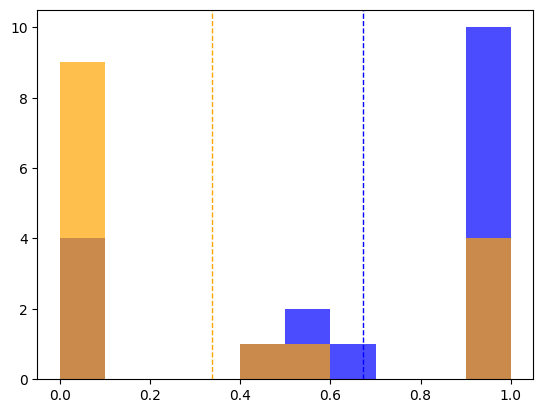

In [ ]:
# Histogram of w_scores of df_nvda

import matplotlib.pyplot as plt
# show hisogram of nvda in blue and qcom in orange

plt.hist(nvda_outlook_df['w_score'], bins=10, color='blue', alpha=0.7)
plt.hist(qcom_outlook_df['w_score'], bins=10, color='orange', alpha=0.7)

# show average w_score of nvda and qcom
plt.axvline(nvda_outlook_df['w_score'].mean(), color='blue', linestyle='dashed', linewidth=1)
plt.axvline(qcom_outlook_df['w_score'].mean(), color='orange', linestyle='dashed', linewidth=1)

# display which color is which company
plt.show()

### **Quantitative Example**

You can output the similar results combined prompting the GPT API more precisely

**Prompt:** I am an investment bank analyst, providing investment ratings based on the text provided by the company's management (Item 7 MD&A section of the 10-K section. Based on the given text only, please answer the following question. How would you rate the stock for the investors? There are five choices: strong buy, buy, hold, sell, strong sell. Please select one of the above five choices and provide a maximum of three-sentence explanation of your choice. The format for the answer to each question should be "choice - explanation."

In [ ]:
prompt = "I am an investment bank analyst, providing investment ratings based on the text provided by the company's management (Item 7 MD&A section of the 10-K section. Based on the given text only, please answer the following question. How would you rate the stock for the investors? There are five choices: strong buy, buy, hold, sell, strong sell. Please select one of the above five choices and provide a maximum of three-sentence explanation of your choice. The format for the answer to each question should be: choice - explanation."

response = client.chat.completions.create(
  model="gpt-3.5-turbo-0125",
  messages=[
      {"role": "system",
       "content": prompt
       },
      {"role": "user",
       "content": item_7_text_nvda
      }
  ]
)

response.choices[0].message.content

"strong buy - The company's financial performance for fiscal year 2025 shows remarkable growth, with revenue up 114% driven by strong demand across all segments, particularly in Data Center and Gaming. The increase in operating income by 147% is impressive, along with the improvement in gross margins to 75.0%. The company's liquidity position, capital return to shareholders, and prudent management of operating expenses further support a strong buy rating for investors."

In [ ]:
nvda_rating = response.choices[0].message.content
print(nvda_rating)

strong buy - The company's financial performance for fiscal year 2025 shows remarkable growth, with revenue up 114% driven by strong demand across all segments, particularly in Data Center and Gaming. The increase in operating income by 147% is impressive, along with the improvement in gross margins to 75.0%. The company's liquidity position, capital return to shareholders, and prudent management of operating expenses further support a strong buy rating for investors.


In [ ]:
prompt = "I am an investment bank analyst, providing investment ratings based on the text provided by the company's management (Item 7 MD&A section of the 10-K section. Based on the given text only, please answer the following question. How would you rate the stock for the investors? There are five choices: strong buy, buy, hold, sell, strong sell. Please select one of the above five choices and provide a maximum of three-sentence explanation of your choice. The format for the answer to each question should be: choice - explanation."

response = client.chat.completions.create(
  model="gpt-3.5-turbo-0125",
  messages=[
      {"role": "system",
       "content": prompt
       },
      {"role": "user",
       "content": item_7_text_qcom
      }
  ]
)

response.choices[0].message.content

'Hold - The company\'s financial performance in fiscal 2024 showed positive results with increased revenues and net income. However, there are uncertainties related to seasonality, potential impact from global minimum tax regulations, and ongoing legal and regulatory proceedings that may pose risks to the business. The company\'s liquidity and capital resources are adequate to meet its obligations in the near term, but factors such as trade relations and competition could impact future performance. Given these mixed factors, a "hold" rating is appropriate for investors seeking a balanced approach.'

In [ ]:
qcom_rating = response.choices[0].message.content
print(qcom_rating)

Hold - The company's financial performance in fiscal 2024 showed positive results with increased revenues and net income. However, there are uncertainties related to seasonality, potential impact from global minimum tax regulations, and ongoing legal and regulatory proceedings that may pose risks to the business. The company's liquidity and capital resources are adequate to meet its obligations in the near term, but factors such as trade relations and competition could impact future performance. Given these mixed factors, a "hold" rating is appropriate for investors seeking a balanced approach.


---
## Chain-of-Thought Buy/Hold/Sell Rating (MD&A Section 7)

We now improve the simple rating prompt by asking the model to **reason step-by-step** before committing to a final recommendation. This *chain-of-thought* (CoT) technique forces the model to surface evidence explicitly, reducing hallucination and making the reasoning auditable.

In [ ]:
cot_prompt = """
You are a senior equity research analyst at a top-tier investment bank.
You will be given the Management Discussion and Analysis (Item 7 MD&A) section of a company's 10-K filing.

Your task is to produce a rigorous investment rating by following these steps IN ORDER:

Step 1 - Key Positives: List the 3-5 most important positive signals about the company's business,
financial performance, or competitive position that you find in the text.

Step 2 - Key Risks: List the 3-5 most important risks, headwinds, or concerns mentioned or implied in the text.

Step 3 - Balance of Evidence: In 2-3 sentences, weigh the positives against the risks and explain
which side is more compelling and why.

Step 4 - Final Rating: State your final investment rating -- choose exactly one of:
Strong Buy | Buy | Hold | Sell | Strong Sell -- and provide a one-sentence justification.

Format your answer exactly as:
Step 1 - Key Positives:\n<bullet points>\n\n
Step 2 - Key Risks:\n<bullet points>\n\n
Step 3 - Balance of Evidence:\n<paragraph>\n\n
Step 4 - Final Rating: <rating> -- <one-sentence justification>
"""

print("Chain-of-thought prompt defined.")

Chain-of-thought prompt defined.


In [ ]:
response_nvda_cot = client.chat.completions.create(
    model="gpt-3.5-turbo-0125",
    messages=[
        {"role": "system", "content": cot_prompt},
        {"role": "user",   "content": item_7_text_nvda}
    ]
)

nvda_cot_bhs = response_nvda_cot.choices[0].message.content
print(nvda_cot_bhs)

Step 1 - Key Positives:
- Revenue growth in fiscal year 2025 was substantial, with an increase of 114% year-over-year.
- Significant growth in Data Center revenue, up 142% from the previous year, driven by demand for the Hopper architecture and Blackwell architecture accelerated computing platforms.
- Gross margin increased to 75.0% in fiscal year 2025, indicating improved profitability.
- Strong growth in operating income, up 147% from the prior year, reflecting operational efficiency and effective cost management.
- Successful product launches in various segments, including Gaming, Professional Visualization, and Automotive, resulting in revenue growth across these areas.

Step 2 - Key Risks:
- Uncertainty surrounding the accuracy of demand estimates for products, applications, and services, which could lead to revenue volatility and supply challenges.
- Complexity in managing multiple suppliers, inventory levels, and supply chain disruptions due to increased complexity of data cente

In [ ]:
response_qcom_cot = client.chat.completions.create(
    model="gpt-3.5-turbo-0125",
    messages=[
        {"role": "system", "content": cot_prompt},
        {"role": "user",   "content": item_7_text_qcom}
    ]
)

qcom_cot_bhs = response_qcom_cot.choices[0].message.content
print(qcom_cot_bhs)

Step 1 - Key Positives:
- Revenue growth: The company reported a 9% increase in revenues in fiscal 2024 compared to the previous year.
- Profitability improvement: Net income increased by 40% year-over-year in fiscal 2024.
- Segment performance: Both QCT and QTL segments saw revenue growth in fiscal 2024.
- Strong financial position: The company experienced an increase in investment and other income, which contributed to higher net income.

Step 2 - Key Risks:
- Seasonal demand: The company's revenues are subject to seasonality and fluctuations in demand for devices. Any deviation in consumer demand or delays in product launches could impact financial performance.
- Regulatory risks: The implementation of global minimum tax regulations, like Pillar Two, could potentially impact the company's financial statements starting in fiscal year 2025.
- Competitive pressures: Intense competition, including vertical integration by customers like Apple, poses a risk to the company's market positio

---
## Financial Statement Analysis (Section 15)

We now fetch the **financial statements** (Item 15 of the 10-K) for each company -- which contains the full audited financials -- and ask GPT to perform:
- **Horizontal analysis**: trends over time (year-over-year changes)
- **Vertical analysis**: common-size structure (each line as % of revenue or total assets)
- **Ratio analysis**: the model selects the most informative ratios given the data available
- **Overall outlook**: a forward-looking assessment of the company's financial health

> **Note:** For these 10-K filings, financial statements appear in **Item 15** (not the standard Item 8).

In [ ]:
# Fetch Item 15 (Financial Statements) for both companies
item_15_text_nvda = extractorApi.get_section(url_10k_nvda, "15", "text")
item_15_text_qcom = extractorApi.get_section(url_10k_qcom, "15", "text")

print(f"NVDA Item 15 length: {len(item_15_text_nvda):,} characters")
print(f"QCOM Item 15 length: {len(item_15_text_qcom):,} characters")

NVDA Item 15 length: 120,993 characters
QCOM Item 15 length: 134,983 characters


In [ ]:
fs_analysis_prompt = """
You are a CFA-chartered financial analyst conducting a thorough analysis of a company's audited financial statements.
You will be given the full text of Item 15 (Financial Statements and Supplementary Data) from the company's 10-K filing.

Perform the following analyses and present them in clearly labeled sections:

Section A -- Horizontal Analysis:
Identify the most meaningful year-over-year changes across the income statement, balance sheet, and cash flow statement.
For each major line item you select, state the direction and magnitude of change and what it signals about the business.

Section B -- Vertical Analysis:
Construct a common-size view of the income statement (as % of total revenues) and the balance sheet (as % of total assets).
Highlight any structural features or line items that stand out as unusually large, small, or changing.

Section C -- Ratio Analysis:
Select the most informative financial ratios given the data available in these statements.
Compute or estimate each ratio, interpret what it means, and flag any ratios that indicate strength or concern.
Cover at minimum: liquidity, solvency/leverage, profitability, and efficiency -- but add any domain-relevant ratios you judge important.

Section D -- Overall Financial Outlook:
Synthesize your findings from Sections A-C into a coherent 3-5 sentence forward-looking assessment.
What do the financials imply about the company's ability to grow, sustain margins, manage risk, and create shareholder value?
Give a final decision Buy-hold-sell.
"""

print("Financial statement analysis prompt defined.")

Financial statement analysis prompt defined.


In [ ]:
# Truncate to model context limit if necessary (gpt-3.5-turbo: ~16k tokens ~= ~35,000 words)
nvda_fs_input = item_15_text_nvda[:35000]

response_nvda_fs = client.chat.completions.create(
    model="gpt-3.5-turbo-0125",
    messages=[
        {"role": "system", "content": fs_analysis_prompt},
        {"role": "user",   "content": nvda_fs_input}
    ]
)

nvda_fs_analysis = response_nvda_fs.choices[0].message.content
print(nvda_fs_analysis)

### Section A -- Horizontal Analysis:

#### Income Statement:
- **Revenue**:
  - **Change**: Revenue increased from $26.9 billion in 2023 to $60.9 billion in 2024, and further to $130.5 billion in 2025.
  - **Magnitude**: The revenue more than doubled year-over-year in both 2024 and 2025.
  - **Insight**: The significant growth in revenue signals a strong demand for the company's products or services, potentially driven by market share gains or new product launches.

- **Gross Profit**:
  - **Change**: Gross profit increased from $15.4 billion in 2023 to $44.3 billion in 2024, and rose further to $97.9 billion in 2025.
  - **Magnitude**: The gross profit more than doubled year-over-year in both 2024 and 2025.
  - **Insight**: The substantial increase in gross profit indicates improved profitability and operational efficiency.

#### Balance Sheet:
- **Total Assets**:
  - **Change**: Total assets increased from $65.7 billion in 2024 to $111.6 billion in 2025.
  - **Magnitude**: The total

In [ ]:
# Truncate to model context limit if necessary (gpt-3.5-turbo: ~16k tokens ~= ~12,000 words)
qcom_fs_input = item_15_text_qcom[:35000]

response_qcom_fs = client.chat.completions.create(
    model="gpt-3.5-turbo-0125",
    messages=[
        {"role": "system", "content": fs_analysis_prompt},
        {"role": "user",   "content": qcom_fs_input}
    ]
)

qcom_fs_analysis = response_qcom_fs.choices[0].message.content
print(qcom_fs_analysis)

### Section A -- Horizontal Analysis:

#### Income Statement:
- Revenues decreased from $44.2 billion in 2022 to $35.8 billion in 2023, a decrease of 19.4%, signaling a decline in sales.
- Operating income decreased from $15.86 billion in 2022 to $7.79 billion in 2023, a decrease of 50.9%, indicating a significant decrease in profitability.
- Net income also saw a decline from $12.94 billion in 2022 to $7.23 billion in 2023, a decrease of 44.1%.

#### Balance Sheet:
- Cash and cash equivalents decreased from $8.53 billion in 2022 to $3.1 billion in 2023, a decrease of 63.7%, indicating a significant reduction in liquidity.
- Total current assets increased from $22.46 billion in 2022 to $25.23 billion in 2023, a 12.4% increase, possibly due to changes in other current assets and deferred tax assets.
- Long-term debt decreased from $14.48 billion in 2022 to $13.27 billion in 2023, a 8.3% reduction, signaling a decreased reliance on debt financing.

#### Cash Flow Statement:
- Net cash pr

---
## Comparative Analysis: NVDA vs. QCOM

Finally, we feed **both financial statement analyses** into GPT and ask for a side-by-side comparison. This mirrors how a portfolio manager would weigh two companies in the same sector before making an allocation decision.

In [ ]:
compare_prompt = """
You are a senior portfolio manager comparing two semiconductor companies -- NVIDIA (NVDA) and Qualcomm (QCOM) --
using financial statement analyses prepared by your analyst team.

You will be given:
- NVDA Financial Analysis: a structured analysis covering horizontal, vertical, ratio analysis, and outlook for NVIDIA.
- QCOM Financial Analysis: the same structured analysis for Qualcomm.

Your task:
1. Head-to-Head Comparison: For each of the four dimensions (horizontal trends, vertical structure, key ratios, outlook),
briefly state which company shows stronger financials and why.

2. Relative Strengths & Weaknesses: What does NVDA do better than QCOM financially? What does QCOM do better than NVDA?

3. Investment Conclusion: If you had to allocate capital to only one of these two companies based solely on
the financial statement evidence, which would you choose and why? Limit this section to 3-4 sentences.
"""

combined_input = (
    "NVDA Financial Analysis:\n" + nvda_fs_analysis +
    "\n\n" +
    "QCOM Financial Analysis:\n" + qcom_fs_analysis
)

response_compare = client.chat.completions.create(
    model="gpt-3.5-turbo-0125",
    messages=[
        {"role": "system", "content": compare_prompt},
        {"role": "user",   "content": combined_input}
    ]
)

nvda_qcom_comparison = response_compare.choices[0].message.content
print(nvda_qcom_comparison)

1. **Head-to-Head Comparison:**

- **Horizontal Analysis:** NVIDIA shows stronger financials in terms of revenue and gross profit growth over the years compared to Qualcomm. NVIDIA's revenue and gross profit more than doubled year-over-year, indicating robust demand and improved profitability.
- **Vertical Analysis:** NVIDIA maintains stronger vertical structures, with increasing gross profit margins and efficiently managing cash compared to Qualcomm, which saw a decrease in gross profit margin.
- **Ratio Analysis:** NVIDIA outperforms Qualcomm in key ratios like liquidity (higher current ratio) and profitability (higher gross profit margin). NVIDIA's decreasing debt-to-equity ratio also signifies lower financial risk.
- **Outlook:** NVIDIA's overall financial outlook appears more positive with impressive growth trends and effective financial management, compared to Qualcomm's challenges in revenue, profitability, and liquidity.

2. **Relative Strengths & Weaknesses:**
   - **NVDA stre